In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"

In [2]:
dtype_to_bytes = {
    "float64": 8,
    "float32": 4,
    "float16": 2,
    "bfloat16": 2,
}

In [3]:
df = pd.read_csv("../results/benchmark_bf16mv_A100.csv")
df

,n,k,dtype,algorithm,time (ms),error norm
0,10000000,2,bfloat16,custom,0.165765,1.959129e-04
1,10000000,2,bfloat16,torch,11.254415,1.484591e+01
2,10000000,2,float16,custom,0.157450,1.960399e-04
3,10000000,2,float16,torch,10.660659,1.855579e+00
4,10000000,2,float32,custom,0.202240,1.961127e-04
...,...,...,...,...,...,...
1019,64523,129,float16,torch,1.624289,9.612926e+00
1020,64523,129,float32,custom,2.682859,6.690046e-03
1021,64523,129,float32,torch,2.733343,4.829840e-03
1022,64523,129,float64,custom,5.191454,1.402218e-11


In [4]:
def throughput(n, k, time_ms, mat_dtype):
    mat_el_bytes = dtype_to_bytes[mat_dtype]
    vec_dtype = "float32" if mat_dtype in ["bfloat16", "float16"] else mat_dtype
    vec_el_bytes = dtype_to_bytes[vec_dtype]
    total_bytes = n * k * k * mat_el_bytes + n * k * vec_el_bytes + n * k * vec_el_bytes
    return total_bytes / (time_ms / 1000) / 1e9

In [5]:
def flops(n, k, time_ms):
    total_flops = 2 * n * k * k
    return total_flops / (time_ms / 1000) / 1e9

In [6]:
df["throughput"] = df.apply(
    lambda row: throughput(
        n=row["n"], k=row["k"], time_ms=row["time (ms)"], mat_dtype=row["dtype"]
    ),
    axis=1,
)
df["GFlops"] = df.apply(
    lambda row: flops(n=row["n"], k=row["k"], time_ms=row["time (ms)"]),
    axis=1,
)
df

,n,k,dtype,algorithm,time (ms),error norm,throughput,GFlops
0,10000000,2,bfloat16,custom,0.165765,1.959129e-04,1447.831781,482.610594
1,10000000,2,bfloat16,torch,11.254415,1.484591e+01,21.324964,7.108321
2,10000000,2,float16,custom,0.157450,1.960399e-04,1524.291129,508.097043
3,10000000,2,float16,torch,10.660659,1.855579e+00,22.512679,7.504226
4,10000000,2,float32,custom,0.202240,1.961127e-04,1582.278408,395.569602
...,...,...,...,...,...,...,...,...
1019,64523,129,float16,torch,1.624289,9.612926e+00,1363.083717,1322.088718
1020,64523,129,float32,custom,2.682859,6.690046e-03,1625.689572,800.434942
1021,64523,129,float32,torch,2.733343,4.829840e-03,1595.664123,785.651419
1022,64523,129,float64,custom,5.191454,1.402218e-11,1680.260025,413.651800


In [7]:
def plot_throughput(ax, dtype: str, labels: bool = False):
    max_tput = df[(df.dtype == dtype) & (df.k <= 128)].pivot_table(
        values="throughput", columns="algorithm", index="k", aggfunc="max"
    )

    vec_dtype = "float32" if dtype in ["bfloat16", "float16"] else dtype
    title = f"{dtype} $\\times$ {vec_dtype}"
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("matrix size k")
    ax.set_ylabel("throughput (GB/s)")

    ax.set_xlim(left=0, right=130)

    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

    ax.scatter(
        x=max_tput.index,
        y=max_tput["custom"],
        marker="^",
        label="Our implementation" if labels else None,
        s=13,
        zorder=3,
        facecolors="none",
        edgecolors="tab:blue",
    )
    ax.scatter(
        x=max_tput.index,
        y=max_tput["torch"],
        marker="o",
        label="PyTorch" if labels else None,
        s=13,
        zorder=2,
        facecolors="none",
        edgecolors="tab:orange",
    )
    ax.axhline(
        y=2039,
        color="red",
        linestyle="--",
        label="A100 bandwidth (2,039GB/s)" if labels else None,
    )

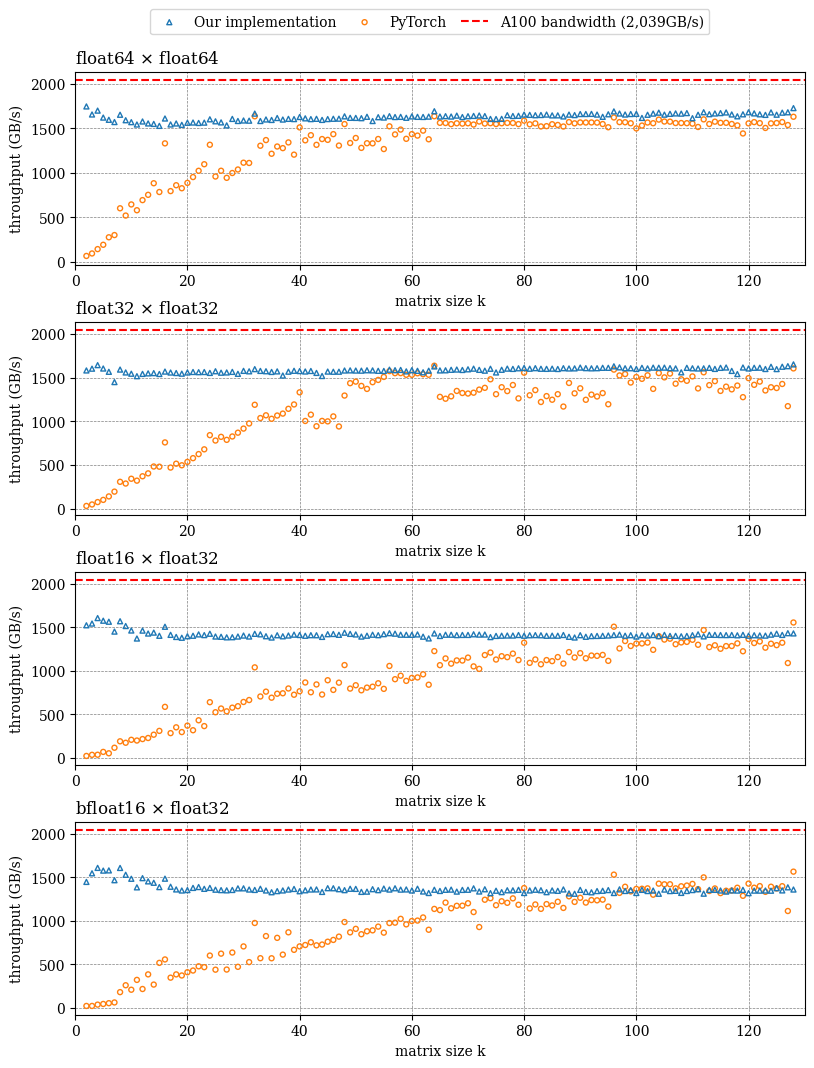

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10))
fig.tight_layout(pad=1.0, h_pad=2.0)
plot_throughput(axes[0], "float64", labels=True)
plot_throughput(axes[1], "float32")
plot_throughput(axes[2], "float16")
plot_throughput(axes[3], "bfloat16")
fig.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.05), columnspacing=1)
fig.savefig("../docs/thesis-media/matrix_vec_tput.svg", bbox_inches="tight")

In [9]:
A100_bandwidth = 2039


def format_list(l):
    return [f"{x:.2f}" for x in l]


for dtype in ["float64", "float32", "float16", "bfloat16"]:
    max_tput = df[(df.dtype == dtype) & (df.k <= 128)].pivot_table(
        values="throughput", columns="algorithm", index="k", aggfunc="max"
    )
    of_max = (max_tput["custom"] / A100_bandwidth).sort_values()
    print(dtype, format_list(list(of_max[:5])), format_list(list(of_max[-5:])))

float64 ['0.75', '0.75', '0.76', '0.76', '0.76'] ['0.83', '0.83', '0.83', '0.85', '0.86']
float32 ['0.71', '0.74', '0.74', '0.75', '0.76'] ['0.80', '0.80', '0.80', '0.81', '0.81']
float16 ['0.67', '0.67', '0.68', '0.68', '0.68'] ['0.76', '0.77', '0.77', '0.77', '0.79']
bfloat16 ['0.64', '0.64', '0.64', '0.65', '0.65'] ['0.76', '0.77', '0.77', '0.79', '0.79']


In [18]:
# For model problems except one (126), the used matrix sizes are 21,24,24,40,60 and dtype float16

# for k in [21, 24, 40, 60]:
tput_pivot = df[df.dtype == "float16"].pivot_table(
    values="throughput", columns="algorithm", index="k", aggfunc="max"
)
used_k = tput_pivot.loc[[21, 24, 40, 60, 126]]
used_k["custom"] / used_k["torch"]

k
21     4.415152
24     2.228014
40     1.843903
60     1.539647
126    1.067815
dtype: float64

In [183]:
def plot_speedup(ax, ref: str, base: str):
    for alg, marker in [("custom", "^"), ("torch", ",")]:
        per_dtype_time = df[df.algorithm == alg].pivot_table(
            values="time (ms)", columns="dtype", index="k"
        )
        speedup = per_dtype_time[base] / per_dtype_time[ref]
        ax.scatter(
            per_dtype_time.index,
            speedup,
            label=f"{alg} {base}/{ref}",
            marker=marker,
        )

    ax.set_title(f"{ref} speedup")
    ax.set_xlabel("matrix size $k$")
    ax.set_ylabel("speedup")

    # dashed grey grid
    ax.grid(which="both", linestyle="--", linewidth=0.5, color="grey")

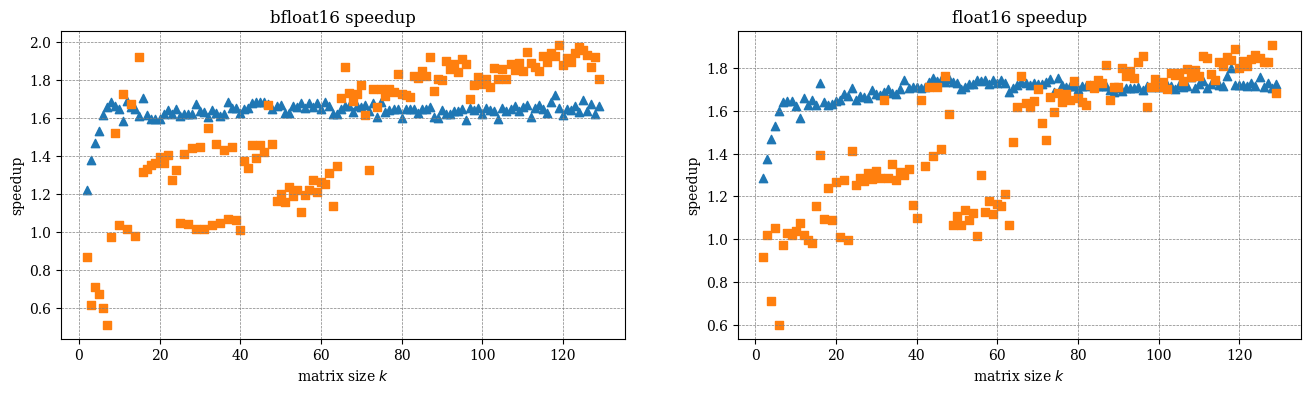

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_speedup(axes[0], ref="bfloat16", base="float32")
plot_speedup(axes[1], ref="float16", base="float32")

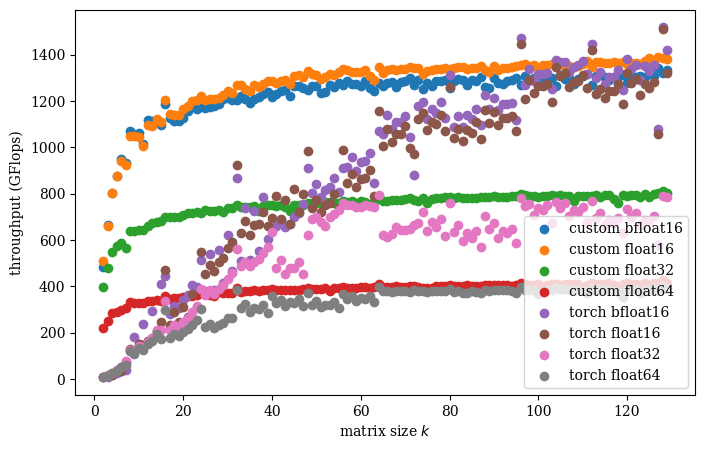

In [185]:
max_tput = df.pivot_table(
    values="GFlops", columns=["algorithm", "dtype"], index="k", aggfunc="max"
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel("matrix size $k$")
ax.set_ylabel("throughput (GFlops)")

for col in max_tput.columns:
    ax.scatter(max_tput.index, max_tput[col], label=col[0] + " " + col[1])

ax.legend(loc="lower right")